=== METHOD 1: Reading all 280000 lines (no header) ===
Reading CSV file: /nas_3/active/minhee2043/NiCoFe/GPR_batch15.csv
CSV shape: (280000, 22)
Columns available: 22
Data processed: 280000 valid values
Data range after subtraction: -4.608 to 19.070


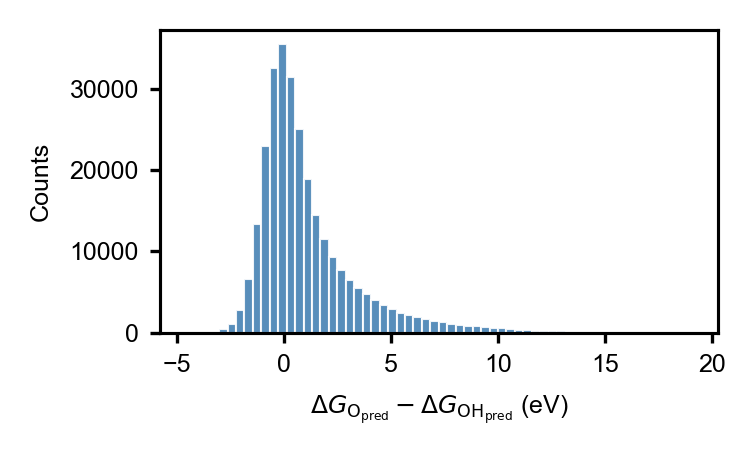


=== SUMMARY STATISTICS ===
Number of data points: 280000
Mean: 1.127 eV
Median: 0.432 eV
Standard deviation: 2.423 eV
Min value: -4.608 eV
Max value: 19.070 eV


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Configure matplotlib with your custom settings
font_path = '/nas/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)
    
config = {
    # Fonts.
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.titlepad': 5,
    'axes.linewidth': 0.75,
    # Figure sizes.
    'figure.figsize': (2.5, 1.5),
    'figure.subplot.wspace': 0.4,
    'figure.subplot.hspace': 0.4,
    # Legends.
    'legend.frameon': False,
    # Figure element aesthetics.
    'lines.linewidth': 0.75,
    'lines.markersize': 3,
    'xtick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.size': 2.5,
    'ytick.major.pad': 2.5,    
    'figure.dpi': 300,
}

plt.rcParams.update(config)

def create_histogram_from_csv(csv_file_path, column_index=18, subtract_value=3.7, has_header=False):
    """
    Create a histogram plot from CSV data
    
    Parameters:
    csv_file_path: str - path to the CSV file
    column_index: int - index of the column to extract (0-based, so 18 for 19th column)
    subtract_value: float - value to subtract from the data
    has_header: bool - whether the CSV file has a header row
    """
    
    try:
        # Read the CSV file
        print(f"Reading CSV file: {csv_file_path}")
        if has_header:
            df = pd.read_csv(csv_file_path)
        else:
            df = pd.read_csv(csv_file_path, header=None)
        
        print(f"CSV shape: {df.shape}")
        print(f"Columns available: {len(df.columns)}")
        
        # Check if the specified column exists
        if column_index >= len(df.columns):
            print(f"Error: Column index {column_index} (19th column) not found.")
            print(f"Available columns: 0 to {len(df.columns)-1}")
            return
        
        # Extract the 19th column (index 18) data
        column_data = df.iloc[:, column_index]
        
        # Convert to numeric, handling any non-numeric values
        numeric_data = pd.to_numeric(column_data, errors='coerce')
        
        # Remove NaN values
        clean_data = numeric_data.dropna()
        
        # Subtract 3.7 from each value
        processed_data = clean_data - subtract_value
        
        print(f"Data processed: {len(clean_data)} valid values")
        print(f"Data range after subtraction: {processed_data.min():.3f} to {processed_data.max():.3f}")
        
        # Create the histogram plot (figure size controlled by rcParams)
        fig, ax = plt.subplots()
        
        # Calculate appropriate number of bins (more bins for thinner bars)
        n_bins = min(60, max(30, int(np.sqrt(len(processed_data)) * 1.0)))
        
        # Create histogram with thinner bars and white borders
        counts, bins, patches = ax.hist(processed_data, bins=n_bins, 
                                       color='steelblue', alpha=0.9, 
                                       edgecolor='white', linewidth=0.5)
        
        # Alternative approach for controlling bar width (if needed):
        # bin_width = (processed_data.max() - processed_data.min()) / n_bins
        # counts, bins, patches = ax.hist(processed_data, bins=n_bins, 
        #                                color='steelblue', alpha=0.9, 
        #                                edgecolor='white', linewidth=0.5,
        #                                rwidth=0.8)
        
        # Customize the plot to match the reference style
        ax.set_xlabel('$\\Delta G_{\\mathrm{O_{pred}}}-\\Delta G_{\\mathrm{OH_{pred}}}$ (eV)')
        ax.set_ylabel('Counts')
        
        # Add grid for better readability
        # ax.grid(True, alpha=0.3, axis='y')
        
        # Set y-axis to start from 0
        ax.set_ylim(bottom=0)
        
        # Add some statistics as text (smaller font for compact figure)
        mean_val = processed_data.mean()
        std_val = processed_data.std()
        
        # Add statistics box (adjusted for smaller figure size)
        stats_text = f'N = {len(processed_data)}\nμ = {mean_val:.2f}\nσ = {std_val:.2f}'
        # ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        #         fontsize=6, verticalalignment='top',
        #         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Improve layout
        plt.tight_layout()
        
        # Show the plot
        plt.show()
        
        # Print summary statistics
        print(f"\n=== SUMMARY STATISTICS ===")
        print(f"Number of data points: {len(processed_data)}")
        print(f"Mean: {mean_val:.3f} eV")
        print(f"Median: {processed_data.median():.3f} eV")
        print(f"Standard deviation: {std_val:.3f} eV")
        print(f"Min value: {processed_data.min():.3f} eV")
        print(f"Max value: {processed_data.max():.3f} eV")
        
        return processed_data
        
    except FileNotFoundError:
        print(f"Error: File '{csv_file_path}' not found.")
        print("Please check the file path and make sure the file exists.")
        return None
        
    except Exception as e:
        print(f"Error reading CSV file: {str(e)}")
        return None

# Alternative function if you want to specify the exact file path
def plot_gpr_batch15_histogram():
    """
    Specific function for your GPR_batch15.csv file
    """
    csv_file_path = '/nas_3/active/minhee2043/NiCoFe/GPR_batch15.csv'
    
    # Call the main function
    data = create_histogram_from_csv(csv_file_path, column_index=18, subtract_value=3.7)
    
    return data

# Example usage with different approaches:

# Approach 1: Use the exact file path (without header)
print("=== METHOD 1: Reading all 280000 lines (no header) ===")
data = create_histogram_from_csv('/nas_3/active/minhee2043/NiCoFe/GPR_batch15.csv', 
                                column_index=18, subtract_value=3.7, has_header=False)


=== Collecting O* DFT data ===
Found 15 files matching pattern: DFT_adsO_b*.csv
  DFT_adsO_b1.csv: 20 data points
  DFT_adsO_b10.csv: 20 data points
  DFT_adsO_b11.csv: 20 data points
  DFT_adsO_b12.csv: 20 data points
  DFT_adsO_b13.csv: 20 data points
  DFT_adsO_b14.csv: 20 data points
  DFT_adsO_b15.csv: 20 data points
  DFT_adsO_b2.csv: 20 data points
  DFT_adsO_b3.csv: 20 data points
  DFT_adsO_b4.csv: 20 data points
  DFT_adsO_b5.csv: 20 data points
  DFT_adsO_b6.csv: 20 data points
  DFT_adsO_b7.csv: 20 data points
  DFT_adsO_b8.csv: 20 data points
  DFT_adsO_b9.csv: 20 data points
\n=== Collecting OH* DFT data ===
Found 15 files matching pattern: DFT_adsOH_b*.csv
  DFT_adsOH_b1.csv: 20 data points
  DFT_adsOH_b10.csv: 20 data points
  DFT_adsOH_b11.csv: 20 data points
  DFT_adsOH_b12.csv: 20 data points
  DFT_adsOH_b13.csv: 20 data points
  DFT_adsOH_b14.csv: 20 data points
  DFT_adsOH_b15.csv: 20 data points
  DFT_adsOH_b2.csv: 20 data points
  DFT_adsOH_b3.csv: 20 data points

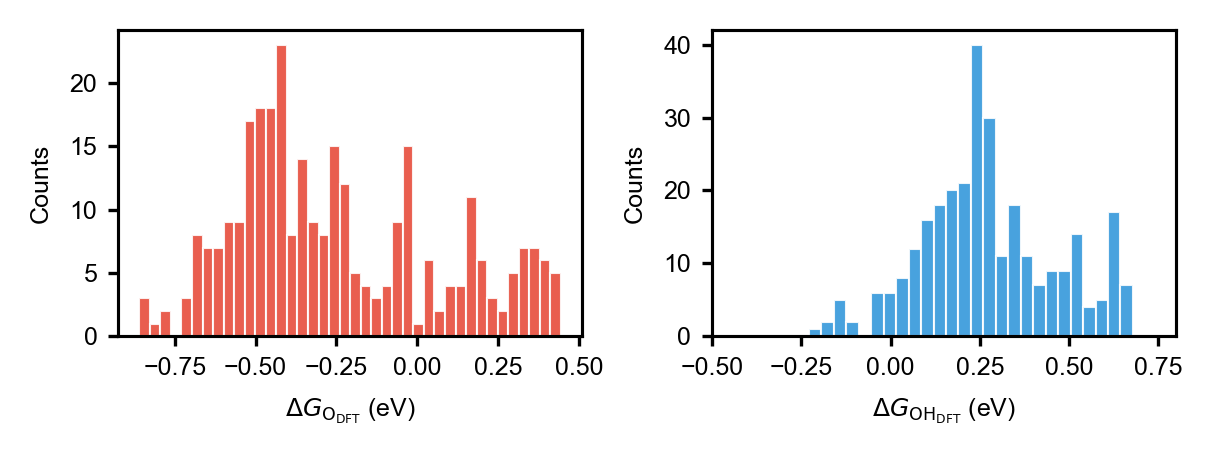

\n=== DETAILED STATISTICS ===
O* DFT Data:
  Mean: -0.246 eV
  Median: -0.325 eV
  Std: 0.319 eV
  Min: -0.859 eV
  Max: 0.444 eV
\nOH* DFT Data:
  Mean: 0.268 eV
  Median: 0.253 eV
  Std: 0.236 eV
  Min: -2.115 eV
  Max: 0.679 eV
\n=== FILE DETAILS ===
O* files:
  DFT_adsO_b1.csv: 20 points
  DFT_adsO_b10.csv: 20 points
  DFT_adsO_b11.csv: 20 points
  DFT_adsO_b12.csv: 20 points
  DFT_adsO_b13.csv: 20 points
  DFT_adsO_b14.csv: 20 points
  DFT_adsO_b15.csv: 20 points
  DFT_adsO_b2.csv: 20 points
  DFT_adsO_b3.csv: 20 points
  DFT_adsO_b4.csv: 20 points
  DFT_adsO_b5.csv: 20 points
  DFT_adsO_b6.csv: 20 points
  DFT_adsO_b7.csv: 20 points
  DFT_adsO_b8.csv: 20 points
  DFT_adsO_b9.csv: 20 points
\nOH* files:
  DFT_adsOH_b1.csv: 20 points
  DFT_adsOH_b10.csv: 20 points
  DFT_adsOH_b11.csv: 20 points
  DFT_adsOH_b12.csv: 20 points
  DFT_adsOH_b13.csv: 20 points
  DFT_adsOH_b14.csv: 20 points
  DFT_adsOH_b15.csv: 20 points
  DFT_adsOH_b2.csv: 20 points
  DFT_adsOH_b3.csv: 20 points
  DFT_

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob
import os

# Configure matplotlib with your custom settings
font_path = '/nas/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)
    
config = {
    # Fonts.
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.titlepad': 5,
    'axes.linewidth': 0.75,
    # Figure sizes - wider for two subplots
    'figure.figsize': (4.0, 1.5),
    'figure.subplot.wspace': 0.4,
    'figure.subplot.hspace': 0.4,
    # Legends.
    'legend.frameon': False,
    # Figure element aesthetics.
    'lines.linewidth': 0.75,
    'lines.markersize': 3,
    'xtick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.size': 2.5,
    'ytick.major.pad': 2.5,    
    'figure.dpi': 300,
}

plt.rcParams.update(config)

def collect_dft_data(base_path, file_pattern, column_index=15, offset=0.0):
    """
    Collect data from multiple DFT CSV files
    
    Parameters:
    base_path: str - directory containing the CSV files
    file_pattern: str - pattern to match files (e.g., 'DFT_adsO_b*.csv')
    column_index: int - column to extract (0-based, so 15 for 16th column)
    offset: float - value to add to the data
    
    Returns:
    combined_data: numpy array of all processed data
    file_info: list of (filename, data_count) tuples
    """
    
    # Find all matching files
    search_pattern = os.path.join(base_path, file_pattern)
    files = glob.glob(search_pattern)
    files.sort()  # Sort for consistent ordering
    
    print(f"Found {len(files)} files matching pattern: {file_pattern}")
    
    all_data = []
    file_info = []
    
    for file_path in files:
        try:
            # Read CSV file without header
            df = pd.read_csv(file_path, header=None)
            
            # Check if column exists
            if column_index >= len(df.columns):
                print(f"Warning: Column {column_index} not found in {os.path.basename(file_path)}")
                continue
            
            # Extract column data
            column_data = df.iloc[:, column_index]
            
            # Convert to numeric and handle NaN
            numeric_data = pd.to_numeric(column_data, errors='coerce')
            clean_data = numeric_data.dropna()
            
            # Apply offset
            processed_data = clean_data + offset
            
            all_data.extend(processed_data.tolist())
            file_info.append((os.path.basename(file_path), len(clean_data)))
            
            print(f"  {os.path.basename(file_path)}: {len(clean_data)} data points")
            
        except Exception as e:
            print(f"Error reading {os.path.basename(file_path)}: {str(e)}")
            continue
    
    return np.array(all_data), file_info

def create_dft_histograms():
    """
    Create histograms for DFT O* and OH* data
    """
    
    base_path = '/nas_3/active/minhee2043/NiCoFe/1.MAE_plot/csv/adsorption'
    
    # Collect O* data (16th column + 0.04)
    print("=== Collecting O* DFT data ===")
    o_data, o_files = collect_dft_data(base_path, 'DFT_adsO_b*.csv', 
                                      column_index=15, offset=0.04)
    
    # Collect OH* data (16th column + 0.35)
    print("\\n=== Collecting OH* DFT data ===")
    oh_data, oh_files = collect_dft_data(base_path, 'DFT_adsOH_b*.csv', 
                                        column_index=15, offset=0.35)
    
    if len(o_data) == 0 or len(oh_data) == 0:
        print("Error: No data collected. Please check file paths and patterns.")
        return None, None
    
    print(f"\\n=== Data Summary ===")
    print(f"O* data: {len(o_data)} total points from {len(o_files)} files")
    print(f"OH* data: {len(oh_data)} total points from {len(oh_files)} files")
    print(f"O* range: {o_data.min():.3f} to {o_data.max():.3f} eV")
    print(f"OH* range: {oh_data.min():.3f} to {oh_data.max():.3f} eV")
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.0, 1.5))
    
    # Calculate bins
    n_bins_o = min(80, max(40, int(np.sqrt(len(o_data)))))
    n_bins_oh = min(160, max(80, int(np.sqrt(len(oh_data)))))
    
    # Plot O* histogram
    counts1, bins1, patches1 = ax1.hist(o_data, bins=n_bins_o, 
                                       color='#e74c3c', alpha=0.9,  # Red color
                                       edgecolor='white', linewidth=0.5)
    
    ax1.set_xlabel('$\\Delta G_{\\mathrm{O_{DFT}}}$ (eV)')
    ax1.set_ylabel('Counts')
    # ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(bottom=0)
    
    # Add statistics for O*
    mean_o = o_data.mean()
    std_o = o_data.std()
    stats_text_o = f'N = {len(o_data)}\\nμ = {mean_o:.2f}\\nσ = {std_o:.2f}'
    # ax1.text(0.02, 0.98, stats_text_o, transform=ax1.transAxes, 
    #         fontsize=6, verticalalignment='top',
    #         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Plot OH* histogram  
    counts2, bins2, patches2 = ax2.hist(oh_data, bins=n_bins_oh, 
                                       color='#3498db', alpha=0.9,  # Blue color
                                       edgecolor='white', linewidth=0.5)
    
    ax2.set_xlabel('$\\Delta G_{\\mathrm{OH_{DFT}}}$ (eV)')
    ax2.set_ylabel('Counts')
    # ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(bottom=0)
    ax2.set_xlim(-0.5,0.8)
    
    # Add statistics for OH*
    mean_oh = oh_data.mean()
    std_oh = oh_data.std()
    stats_text_oh = f'N = {len(oh_data)}\\nμ = {mean_oh:.2f}\\nσ = {std_oh:.2f}'
    # ax2.text(0.02, 0.98, stats_text_oh, transform=ax2.transAxes, 
    #         fontsize=6, verticalalignment='top',
    #         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\\n=== DETAILED STATISTICS ===")
    print(f"O* DFT Data:")
    print(f"  Mean: {mean_o:.3f} eV")
    print(f"  Median: {np.median(o_data):.3f} eV") 
    print(f"  Std: {std_o:.3f} eV")
    print(f"  Min: {o_data.min():.3f} eV")
    print(f"  Max: {o_data.max():.3f} eV")
    
    print(f"\\nOH* DFT Data:")
    print(f"  Mean: {mean_oh:.3f} eV")
    print(f"  Median: {np.median(oh_data):.3f} eV")
    print(f"  Std: {std_oh:.3f} eV") 
    print(f"  Min: {oh_data.min():.3f} eV")
    print(f"  Max: {oh_data.max():.3f} eV")
    
    print(f"\\n=== FILE DETAILS ===")
    print("O* files:")
    for filename, count in o_files:
        print(f"  {filename}: {count} points")
    
    print("\\nOH* files:")
    for filename, count in oh_files:
        print(f"  {filename}: {count} points")
    
    return o_data, oh_data

# Run the analysis
if __name__ == "__main__":
    o_data, oh_data = create_dft_histograms()
    
    # Optional: Save data for later use
    if o_data is not None and oh_data is not None:
        # Uncomment to save processed data
        # np.savetxt('o_dft_data.txt', o_data)
        # np.savetxt('oh_dft_data.txt', oh_data)
        print(f"\\nData collection complete!")

Reading and processing data...
Successfully processed 280000 surface motifs
Energy range: -0.908 to 22.770 eV
Total weight: 1.000000


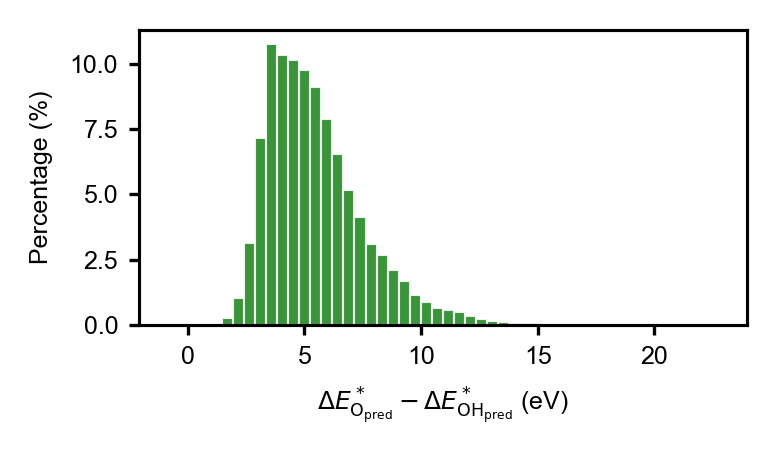

\n=== DETAILED STATISTICS ===
Number of surface motifs: 280000
Weighted mean energy: 5.500 eV
Unweighted mean energy: 4.827 eV
Energy std deviation: 2.423 eV
Min energy: -0.908 eV
Max energy: 22.770 eV
Total probability weight: 1.000000e+00
Max weight: 1.711342e-03
Min weight: 1.000000e-18
\n=== WEIGHT EXPLANATION ===
The decimal weights represent:
- Probability of composition × Multiplicity
- NOT percentages, but probability values
- Small values are normal (many rare compositions)
- Total should sum to ~1 if all compositions are represented
\n=== WEIGHT DISTRIBUTION ===
Weight percentiles:
  1%: 1.57e-13
  5%: 7.42e-12
 25%: 1.36e-09
 50%: 3.34e-08
 75%: 5.29e-07
 95%: 1.31e-05
 99%: 7.24e-05
\nHistogram created successfully!


In [ ]:
import math
import pandas as pd
import csv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import pyplot
from matplotlib import font_manager as fm
import seaborn as sns
from matplotlib.cm import get_cmap

font_path = '/nas/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)

config = {
    # Fonts.
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.titlepad': 5,
    'axes.linewidth': 0.75,
    # Figure sizes - compact for single plot
    'figure.figsize': (2.5, 1.5),
    'figure.subplot.wspace': 0.4,
    'figure.subplot.hspace': 0.4,
    # Legends.
    'legend.frameon': False,
    # Figure element aesthetics.
    'lines.linewidth': 0.75,
    'lines.markersize': 3,
    'xtick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.size': 2.5,
    'ytick.major.pad': 2.5,    
    'figure.dpi': 300,
}

plt.rcParams.update(config)

# Constants
kb = 8.617333262 * math.pow(10, -5)
T = 300
E_opt = 5.3

# Initialize lists to store data
energies = []
weights = []

# Read the CSV file and process data
file_path = '/nas_3/active/minhee2043/NiCoFe/GPR_batch15.csv'

print("Reading and processing data...")

with open(file_path, 'r') as file:
    csvreader = csv.reader(file)
    
    for row in csvreader:
        try:
            # Calculate alloy composition probabilities
            # Assuming: 0=Ni (55%), 1=Fe (35%), 2=Co (10%)
            ni_count = int(row[0]) + int(row[3]) + int(row[6]) + int(row[9]) + int(row[12])
            fe_count = int(row[1]) + int(row[4]) + int(row[7]) + int(row[10]) + int(row[13])
            co_count = int(row[2]) + int(row[5]) + int(row[8]) + int(row[11]) + int(row[14])
            
            # Calculate possibility based on composition
            possibility = (math.pow(0.55, ni_count) * 
                            math.pow(0.35, fe_count) * 
                            math.pow(0.1, co_count))
            
            # Get multiplicity from 16th element (index 15)
            multiplicity = int(row[15])
            
            # Calculate final weight
            final_weight = possibility * multiplicity
            
            # Get energy from 19th element (index 18)
            energy = float(row[18])
            
            # Store data
            energies.append(energy)
            weights.append(final_weight)
            
        except (ValueError, IndexError) as e:
            print(f"Error processing row: {e}")
            continue

print(f"Successfully processed {len(energies)} surface motifs")
print(f"Energy range: {min(energies):.3f} to {max(energies):.3f} eV")
print(f"Total weight: {sum(weights):.6f}")

# Convert to numpy arrays for easier handling
energies = np.array(energies)
weights = np.array(weights)

# Set number of bins for histogram
n_bins = 50

# Calculate weighted mean energy
mean_energy = np.average(energies, weights=weights)
total_weight = np.sum(weights)

# Normalize weights to percentages
weights_percentage = (weights / np.sum(weights)) * 100

# Create the histogram plot
fig, ax = plt.subplots()  # Uses config figsize automatically

# Create histogram with percentage weights
hist_pct, bins_pct, patches_pct = ax.hist(energies, bins=n_bins, weights=weights_percentage,
                                         color='forestgreen', alpha=0.9,
                                         edgecolor='white', linewidth=0.5)

# Set labels (fontsize controlled by config)
ax.set_xlabel('$\\E^*_{\\mathrm{O_{pred}}}-\\E^*_{\\mathrm{OH_{pred}}}$ (eV)')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(bottom=0)


# Calculate statistics for percentage version
mean_energy_pct = np.average(energies, weights=weights_percentage)
total_pct = np.sum(weights_percentage)

# Add statistics text box (scaled for small figure)
stats_text_pct = f'N = {len(energies)}\\nμ = {mean_energy_pct:.2f} eV\\nTotal = {total_pct:.0f}%'

# Apply tight layout and show
plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\\n=== DETAILED STATISTICS ===")
print(f"Number of surface motifs: {len(energies)}")
print(f"Weighted mean energy: {mean_energy:.3f} eV")
print(f"Unweighted mean energy: {np.mean(energies):.3f} eV")
print(f"Energy std deviation: {np.std(energies):.3f} eV")
print(f"Min energy: {np.min(energies):.3f} eV")
print(f"Max energy: {np.max(energies):.3f} eV")
print(f"Total probability weight: {np.sum(weights):.6e}")
print(f"Max weight: {np.max(weights):.6e}")
print(f"Min weight: {np.min(weights):.6e}")

print(f"\\n=== WEIGHT EXPLANATION ===")
print("The decimal weights represent:")
print(f"- Probability of composition × Multiplicity")
print(f"- NOT percentages, but probability values")
print(f"- Small values are normal (many rare compositions)")
print(f"- Total should sum to ~1 if all compositions are represented")

# Show weight distribution
print(f"\\n=== WEIGHT DISTRIBUTION ===")
weight_stats = np.percentile(weights, [1, 5, 25, 50, 75, 95, 99])
print(f"Weight percentiles:")
print(f"  1%: {weight_stats[0]:.2e}")
print(f"  5%: {weight_stats[1]:.2e}")
print(f" 25%: {weight_stats[2]:.2e}")
print(f" 50%: {weight_stats[3]:.2e}")
print(f" 75%: {weight_stats[4]:.2e}")
print(f" 95%: {weight_stats[5]:.2e}")
print(f" 99%: {weight_stats[6]:.2e}")

# Optional: Save the plot
# plt.savefig('surface_motif_histogram.pdf', bbox_inches='tight', dpi=300)
print("\\nHistogram created successfully!")